# Null Value Imputation

Notebook purpose is to do some NULL value analysis and impute missing values based on what is nearby

First just import packages

In [ ]:
# !pip install uv
# !uv pip install  -r requirements.txt
#
# #new library
# !pip install mlxtend


In [1]:
## import packages

# import snowflake
# from snowflake.snowpark.context import get_active_session
# session = get_active_session()

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np
import pandas as pd
from IPython.display import display

# Multi-dimensional arrays and datasets (e.g., NetCDF, Zarr)
import xarray as xr

# Geospatial raster data handling with CRS support
import rioxarray as rxr

# Raster operations and spatial windowing
import rasterio
from rasterio.windows import Window

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Planetary Computer tools for STAC API access and authentication
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
from pystac.extensions.eo import EOExtension as eo

from datetime import date
from tqdm import tqdm
import os 

#NEW PACKAGES
import planetary_computer 
import dask 
from scipy import stats
from scipy.special import inv_boxcox

from datetime import datetime
from dask.distributed import Client

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.feature_selection import RFECV
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
from sklearn.impute import KNNImputer
import statsmodels.api as sm

import xgboost as xgb

import datetime as dt


import re


# def run_groupkfold_cv(X, y, groups, n_splits=5, param_name="Parameter"):
#     gkf = GroupKFold(n_splits=n_splits)
#     fold_results = []
#
#     for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
#         # print(f"\n=== Fold {fold+1} ===")
#
#         # Split
#         X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]
#
#         # Scale
#         X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)
#
#         # Train
#         model = train_model(X_train_scaled, y_train)
#
#         # Evaluate (in-sample)
#         y_train_pred, r2_train, rmse_t
#         # Evaluate (out-sample)rain = evaluate_model(model, X_train_scaled, y_train, "Train")
#
#         y_test_pred, r2_test, rmse_test = evaluate_model(model, X_test_scaled, y_test, "Test")
#
#         fold_results.append((r2_train, rmse_train, r2_test, rmse_test))
#
#     df_results_kfold = pd.DataFrame(fold_results, columns=['R2_Train', 'RMSE_Train', 'R2_Test', 'RMSE_Test']).reset_index().rename(columns={"index": "fold"})
#     df_results_kfold['Parameter'] = param_name
#     df_results_kfold['Features'] = ', '.join([col for col in X.columns if col != 'sample_location_group'])
#     df_results_kfold = df_results_kfold[['Parameter', 'Features', 'R2_Train', 'RMSE_Train', 'R2_Test', 'RMSE_Test']]
#
#     return df_results_kfold


In [2]:
Water_Quality_df = pd.read_csv("data/water_quality_training_dataset.csv")
landsat_train_features = pd.read_csv("data/landsat/landsat_features_training_all_bands.csv")
Terraclimate_df = pd.read_csv("data/terraclimate_features_training_combined.csv")

#Clean Up the Data
#Capitalize Col Names
def capitalize_words_keep_spacing(col):
    # Split on space or underscore but keep the separators
    parts = re.split(r'([ _])', col)
    # Capitalize text parts, keep separators unchanged
    return ''.join(p.title() if p not in [' ', '_'] else p for p in parts)
Terraclimate_df.columns = [capitalize_words_keep_spacing(c) for c in Terraclimate_df.columns]
landsat_train_features.columns = [capitalize_words_keep_spacing(c) for c in landsat_train_features.columns]
Water_Quality_df.columns = [capitalize_words_keep_spacing(c) for c in Water_Quality_df.columns]

def combine_two_datasets(dataset1,dataset2,dataset3):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2,dataset3], axis=1)
    data = data.loc[:, ~data.columns.duplicated()]
    return data

wq_data = combine_two_datasets(Water_Quality_df, landsat_train_features, Terraclimate_df)

#Data type corrections 
wq_data['Sample Date'] = pd.to_datetime(wq_data['Sample Date'],  format='%d-%m-%Y')


def convert_text_cols_to_float(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if (pd.api.types.is_object_dtype(out[c]) 
            or pd.api.types.is_string_dtype(out[c]) 
            or pd.api.types.is_categorical_dtype(out[c])):
            s = out[c].astype(str).str.replace('\u00A0', ' ', regex=False).str.strip()
            s = s.str.replace('\u2212', '-', regex=False)                 # unicode minus
            s = s.str.replace(r'^\(\s*(.*)\s*\)$', r'-\1', regex=True)    # (123) -> -123
            s = s.str.replace(r'^\s*([+]?\s*[\d, .]+)\s*-$', r'-\1', regex=True)  # 123- -> -123
            s = s.str.replace(r'(?<=\d),(?=\d{3}\b)', '', regex=True)      # thousands comma
            out[c] = pd.to_numeric(s, errors='coerce')                     # float64 by default with NaNs
    return out

wq_data = convert_text_cols_to_float(wq_data)


wq_data = wq_data[['Latitude', 'Longitude', 'Sample Date', 'Red', 'Blue', 'Drad', 'Emis', 'Emsd', 'Lwir', 'Trad', 'Urad', 'Atran', 'Cdist', 'Green', 'Nir08', 'Swir16', 'Swir22', 'Atmos_Opacity']]

Water_Quality_df_v = pd.read_csv("data/submission_template.csv")
landsat_train_features_v = pd.read_csv("data/landsat_features_validation_combined.csv")
Terraclimate_df_v = pd.read_csv("data/terraclimate_features_validation_combined.csv")

#Clean Up the Data
Terraclimate_df_v.columns = [capitalize_words_keep_spacing(c) for c in Terraclimate_df_v.columns]
landsat_train_features_v.columns = [capitalize_words_keep_spacing(c) for c in landsat_train_features_v.columns]
Water_Quality_df_v.columns = [capitalize_words_keep_spacing(c) for c in Water_Quality_df_v.columns]

wq_data_v = combine_two_datasets(Water_Quality_df_v, landsat_train_features_v, Terraclimate_df_v)

#Data type corrections 
wq_data_v['Sample Date'] = pd.to_datetime(wq_data_v['Sample Date'],  format='%d-%m-%Y')
wq_data_v = convert_text_cols_to_float(wq_data_v)

wq_data_v = wq_data_v.drop(columns=['Qa_Radsat', 'Cloud_Qa'])
#ullify all negative observations
for column in wq_data_v.columns:
    if column != "Sample Date": wq_data_v[wq_data_v[column] < -9000][column] = np.nan 

wq_data_v = wq_data_v[['Latitude', 'Longitude', 'Sample Date', 'Red', 'Blue', 'Drad', 'Emis', 'Emsd', 'Lwir', 'Trad', 'Urad', 'Atran', 'Cdist', 'Green', 'Nir08', 'Swir16', 'Swir22', 'Atmos_Opacity']]

KeyError: "['Qa_Radsat', 'Cloud_Qa'] not found in axis"

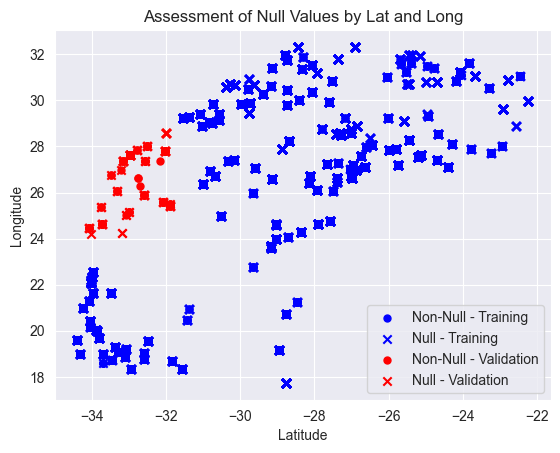

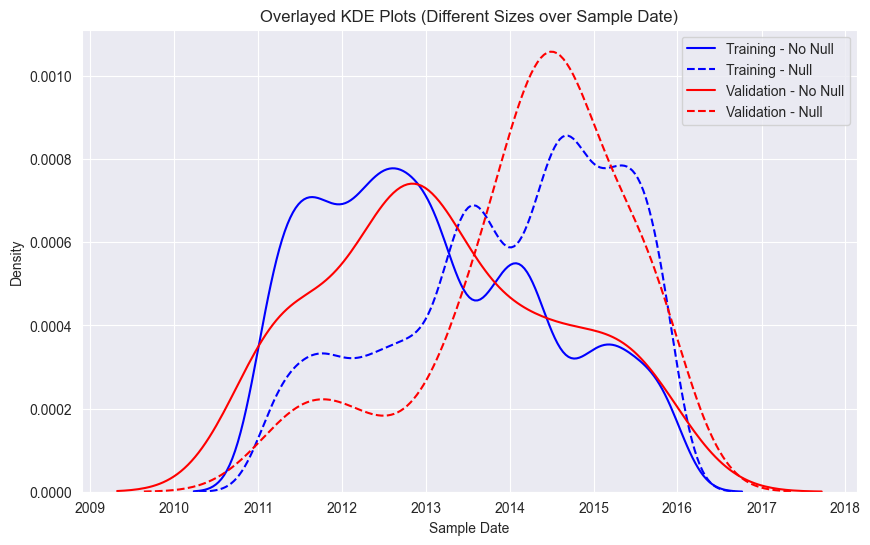

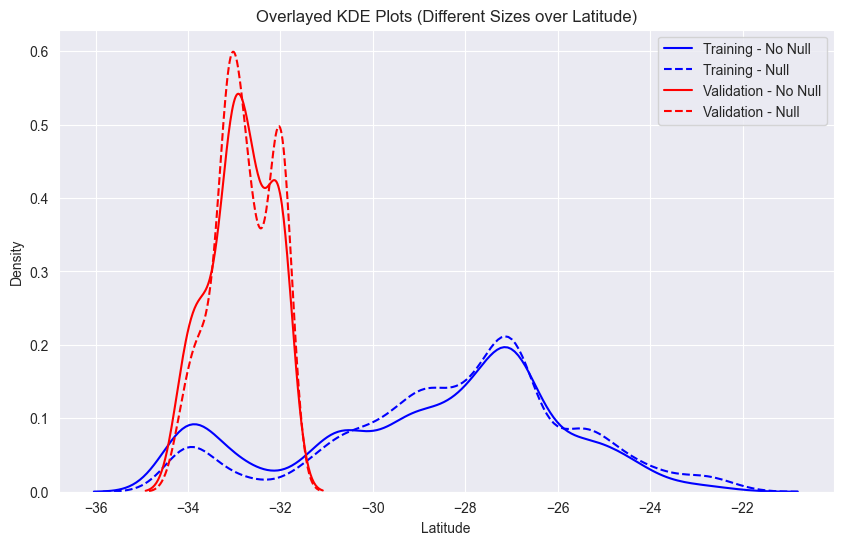

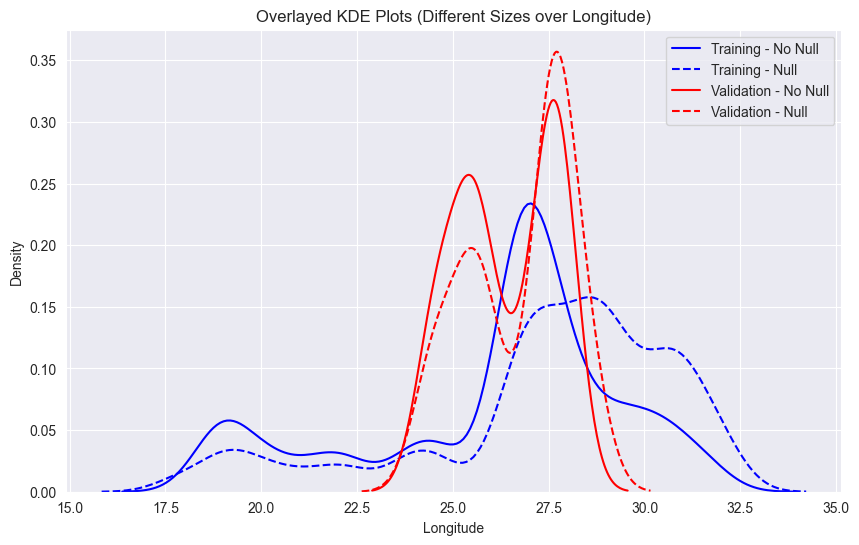

In [47]:
wq_data_nonullvalues = wq_data.dropna(how='any',axis=0)
wq_data_nullvalues = wq_data[wq_data.isnull().any(axis=1)]

wq_data_nonullvalues_v = wq_data_v.dropna(how='any',axis=0)
wq_data_nullvalues_v = wq_data_v[wq_data_v.isnull().any(axis=1)]

plt.scatter(wq_data_nonullvalues["Latitude"], wq_data_nonullvalues["Longitude"] , color='blue', label='Non-Null - Training', marker='.', s=100)

plt.scatter(wq_data_nullvalues["Latitude"], wq_data_nullvalues["Longitude"] , color='blue', label='Null - Training', marker='x')

plt.scatter(wq_data_nonullvalues_v["Latitude"], wq_data_nonullvalues_v["Longitude"] , color='red', label='Non-Null - Validation', marker='.', s=100)

plt.scatter(wq_data_nullvalues_v["Latitude"], wq_data_nullvalues_v["Longitude"] , color='red', label='Null - Validation', marker='x')

# Add labels, a title, and a legend
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Assessment of Null Values by Lat and Long')
plt.legend() # Displays the labels we set in plt.scatter()

# Display the plot
plt.show()

# Plotting
plt.figure(figsize=(10, 6))
sns.kdeplot(data=wq_data_nonullvalues['Sample Date'], fill=False, label='Training - No Null', common_norm=False, color = "Blue")
sns.kdeplot(data=wq_data_nullvalues['Sample Date'], fill=False, label='Training - Null', common_norm=False, color = "Blue", ls='--')
sns.kdeplot(data=wq_data_nonullvalues_v['Sample Date'], fill=False, label='Validation - No Null', common_norm=False, color = "Red")
sns.kdeplot(data=wq_data_nullvalues_v['Sample Date'], fill=False, label='Validation - Null', common_norm=False, color = "Red", ls='--')
plt.title('Overlayed KDE Plots (Different Sizes over Sample Date)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=wq_data_nonullvalues['Latitude'], fill=False, label='Training - No Null', common_norm=False, color = "Blue")
sns.kdeplot(data=wq_data_nullvalues['Latitude'], fill=False, label='Training - Null', common_norm=False, color = "Blue", ls='--')
sns.kdeplot(data=wq_data_nonullvalues_v['Latitude'], fill=False, label='Validation - No Null', common_norm=False, color = "Red")
sns.kdeplot(data=wq_data_nullvalues_v['Latitude'], fill=False, label='Validation - Null', common_norm=False, color = "Red", ls='--')
plt.title('Overlayed KDE Plots (Different Sizes over Latitude)')
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
sns.kdeplot(data=wq_data_nonullvalues['Longitude'], fill=False, label='Training - No Null', common_norm=False, color = "Blue")
sns.kdeplot(data=wq_data_nullvalues['Longitude'], fill=False, label='Training - Null', common_norm=False, color = "Blue", ls='--')
sns.kdeplot(data=wq_data_nonullvalues_v['Longitude'], fill=False, label='Validation - No Null', common_norm=False, color = "Red")
sns.kdeplot(data=wq_data_nullvalues_v['Longitude'], fill=False, label='Validation - Null', common_norm=False, color = "Red", ls='--')
plt.title('Overlayed KDE Plots (Different Sizes over Longitude)')
plt.legend()
plt.show()

## Imputation Function HERE

The function that takes in the dataframe and imputes all the missing values is in the following code block. This is all that needs to be copied and pasted into an existing notebook

Best parameter choices are in the usage section below

In [8]:
def imputevals_latlongdate(df: pd.DataFrame, nearest_neighbours, weighted, dist) -> pd.DataFrame:
    
    if not all(col in df.columns for col in ['latitude', 'longitude', 'sample date']):
        missing = [c for c in ['latitude', 'longitude', 'sample date'] if c not in df.columns]
        raise KeyError(f"Missing required columns: {missing}")

    referencedate = dt.date(2000, 1, 1)
    
    date_series = pd.to_datetime(df['sample date'], errors='coerce', utc=True)
    reference_date = pd.Timestamp('1970-01-01', tz='UTC')
    #  Days since the reference (as float)
    date_days = (date_series - reference_date).dt.total_seconds() / (24 * 60 * 60)
    date_days = date_days.to_numpy()

    lon = pd.to_numeric(df['longitude'], errors='coerce').astype(float)
    lat = pd.to_numeric(df['latitude'], errors='coerce').astype(float)

    dist_mat = np.column_stack([lon.to_numpy(), lat.to_numpy(), date_days])
    scaler = StandardScaler()
    dist_scaled = scaler.fit_transform(dist_mat)  # shape (N, 3)
    dist_scaled[:, 2] *= 0.333 #this can be tweaked - to penalize or unpenalize specific values
    
    out = df.copy()
    for c in out.columns:
        if c in ['latitude', 'longitude', 'sample date']:
            continue
        else:        
            c_vals = pd.to_numeric(out[c], errors='coerce').to_numpy(dtype=float)
            temp = np.column_stack([dist_scaled, c_vals])
            # Run KNNImputer (use distance weighting if you prefer)
            imputer = KNNImputer(n_neighbors=nearest_neighbours, weights=weighted, metric = dist)
            imputed_arr = imputer.fit_transform(temp)
            out[c] = imputed_arr[:, -1]
    return out

  
  #USAGE
  # df_nonull = imputevals_latlongdate(df, nearest_neighbours = 6, weighted = 'distance', dist='nan_euclidean')


In [49]:
landsat_val_features = pd.read_csv("data/landsat/landsat_features_validation_all_bands.csv")

In [72]:
for col in landsat_train_features.columns:
    landsat_train_features[col] = landsat_train_features[col].replace(-9999.0, np.nan)

for col in landsat_val_features.columns:
    landsat_val_features[col] = landsat_val_features[col].replace(-9999.0, np.nan)

In [73]:
df_nonull = imputevals_latlongdate(landsat_train_features, nearest_neighbours = 6, weighted = 'distance', dist='nan_euclidean')
df_nonull_val = imputevals_latlongdate(landsat_val_features, nearest_neighbours = 6, weighted = 'distance', dist='nan_euclidean')

In [10]:
df_train = pd.read_csv("data/depWaterAndSan/depWaterAndSan_features_training_chemReadings.csv")
df_val = pd.read_csv("data/depWaterAndSan/depWaterAndSan_features_validation_chemReadings.csv")

In [11]:
df_sa_nonull = imputevals_latlongdate(df_train, nearest_neighbours = 6, weighted = 'distance', dist='nan_euclidean')
df_sa_nonull_val = imputevals_latlongdate(df_val, nearest_neighbours = 6, weighted = 'distance', dist='nan_euclidean')

In [14]:
for col in df_sa_nonull.columns:
    df_sa_nonull.rename(columns={col:col.lower()}, inplace=True)
df_sa_nonull.to_csv("data/depWaterAndSan/depWaterAndSan_features_training_chemReadings_nonnull.csv", index=False)

for col in df_sa_nonull_val.columns:
    df_sa_nonull_val.rename(columns={col:col.lower()}, inplace=True)
df_sa_nonull_val.to_csv("data/depWaterAndSan/depWaterAndSan_features_validation_chemReadings_nonnull.csv", index=False)

In [12]:
df_train.isna().sum()

latitude                      0
longitude                     0
sample date                   0
mg_diss_water_dl            949
cl_diss_water_dl            966
ca_diss_water_dl           1065
no3_no2_n_diss_water_dl    1207
cl_diss_water               966
ec_phys_water               487
ph_diss_water_dl            496
no3_no2_n_diss_water       1188
nh4_n_diss_water_dl         609
na_diss_water_dl           1340
tal_diss_water             1388
ph_diss_water               415
na_diss_water              1340
po4_p_diss_water            546
mg_diss_water               949
nh4_n_diss_water            609
so4_diss_water              905
f_diss_water_dl            1852
ca_diss_water              1065
ec_phys_water_dl            499
f_diss_water               1852
po4_p_diss_water_dl         546
tal_diss_water_dl          1388
so4_diss_water_dl           907
dtype: int64

In [13]:
df_sa_nonull.isna().sum()

latitude                   0
longitude                  0
sample date                0
mg_diss_water_dl           0
cl_diss_water_dl           0
ca_diss_water_dl           0
no3_no2_n_diss_water_dl    0
cl_diss_water              0
ec_phys_water              0
ph_diss_water_dl           0
no3_no2_n_diss_water       0
nh4_n_diss_water_dl        0
na_diss_water_dl           0
tal_diss_water             0
ph_diss_water              0
na_diss_water              0
po4_p_diss_water           0
mg_diss_water              0
nh4_n_diss_water           0
so4_diss_water             0
f_diss_water_dl            0
ca_diss_water              0
ec_phys_water_dl           0
f_diss_water               0
po4_p_diss_water_dl        0
tal_diss_water_dl          0
so4_diss_water_dl          0
dtype: int64

In [76]:
landsat_train_features[landsat_train_features["Green"].isna()]

,Latitude,Longitude,Sample Date,Emis,Atran,Swir16,Atmos_Opacity,Green,Drad,Red,Swir22,Emsd,Cdist,Nir08,Blue,Trad,Lwir,Urad
12,-33.501667,21.624167,04-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,-29.160278,26.573333,11-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,-31.104278,29.399722,18-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,-24.396194,27.089833,19-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,-30.570833,29.150556,19-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9232,-34.329722,18.990278,03-12-2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9267,-33.897778,20.012778,12-01-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9271,-33.897778,20.012778,19-06-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9275,-33.897778,20.012778,18-01-2013,NaN,6134.0,NaN,NaN,NaN,1413.0,NaN,NaN,NaN,NaN,NaN,NaN,9004.0,NaN,3123.0


In [77]:
df_nonull[landsat_train_features["Green"].isna()]

,Latitude,Longitude,Sample Date,Emis,Atran,Swir16,Atmos_Opacity,Green,Drad,Red,Swir22,Emsd,Cdist,Nir08,Blue,Trad,Lwir,Urad
12,-33.501667,21.624167,04-01-2011,9633.500000,7830.000000,11745.750000,11.000000,9487.916667,919.666667,9348.833333,9656.250000,65.000000,563.250000,14045.916667,8620.333333,8381.500000,42688.166667,1551.166667
36,-29.160278,26.573333,11-01-2011,551.811594,6351.750000,13971.333333,-1618.166667,5006.000000,393.250000,10638.750000,12707.083333,84.666667,168.250000,13832.750000,4481.500000,7814.583333,43871.083333,773.166667
59,-31.104278,29.399722,18-01-2011,9751.000000,6093.500000,11166.916667,40.250000,9331.916667,-309.333333,9374.750000,10002.166667,26.000000,2744.833333,13517.083333,8550.083333,8761.750000,43720.500000,1680.333333
64,-24.396194,27.089833,19-01-2011,9580.750000,8073.166667,12150.416667,14.666667,9520.416667,892.666667,9710.500000,9833.416667,-2349.000000,1572.083333,12598.833333,8517.666667,8787.333333,40434.500000,955.500000
71,-30.570833,29.150556,19-01-2011,9688.000000,8020.166667,13989.000000,10.166667,10027.000000,460.666667,11351.583333,12217.750000,51.500000,1026.750000,13696.750000,8795.500000,7787.250000,42851.750000,893.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9232,-34.329722,18.990278,03-12-2015,9613.000000,8093.500000,10216.666667,14.333333,9192.000000,758.333333,9528.333333,9995.666667,60.000000,132.333333,10319.500000,8632.250000,8359.750000,46892.000000,1177.333333
9267,-33.897778,20.012778,12-01-2012,9679.333333,8646.166667,11952.500000,10.666667,8816.333333,726.666667,8741.500000,8983.500000,42.000000,1490.000000,17356.666667,8725.500000,8907.333333,43546.666667,1323.500000
9271,-33.897778,20.012778,19-06-2012,9675.500000,7674.333333,10706.500000,8.833333,8741.500000,917.000000,8593.666667,9022.166667,42.000000,1612.500000,13968.833333,8187.833333,8631.500000,42676.333333,1664.000000
9275,-33.897778,20.012778,18-01-2013,9675.500000,6134.000000,10706.500000,8.833333,8741.500000,1413.000000,8593.666667,9022.166667,42.000000,1612.500000,13968.833333,8187.833333,9004.000000,42676.333333,3123.000000


In [78]:
landsat_val_features[landsat_val_features["green"].isna()]

,Latitude,Longitude,Sample Date,lwir,green,cdist,blue,swir22,drad,atmos_opacity,urad,trad,emis,emsd,nir08,atran,red,swir16
1,-33.329167,26.077500,16-09-2015,NaN,NaN,NaN,NaN,NaN,-4676.5,NaN,-4355.0,-702.0,NaN,NaN,NaN,-827.5,NaN,NaN
3,-34.096389,24.439167,07-02-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,-33.185361,27.390750,22-09-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,-33.185361,27.390750,31-05-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,-32.579167,27.366667,07-05-2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,-32.991639,27.640028,02-06-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,-32.991639,27.640028,14-01-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,-34.096389,24.439167,12-10-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,-32.991639,27.640028,28-09-2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,-33.202778,24.235556,30-05-2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
df_nonull_val[landsat_val_features["green"].isna()]

,Latitude,Longitude,Sample Date,lwir,green,cdist,blue,swir22,drad,atmos_opacity,urad,trad,emis,emsd,nir08,atran,red,swir16
1,-33.329167,26.077500,16-09-2015,42072.949605,9019.700000,2021.800000,8164.700000,9322.000000,-4676.500000,9.000000,-4355.000000,-702.000000,9804.600000,59.000000,13127.000000,-827.500000,9139.700000,11053.200000
3,-34.096389,24.439167,07-02-2012,46607.000000,8339.700000,279.300000,7816.000000,8787.000000,907.200000,71.000000,1896.800000,9162.200000,9761.800000,36.200000,14525.076258,7658.600000,8058.700000,10690.600000
9,-33.185361,27.390750,22-09-2011,43928.500000,9339.500000,1061.916667,8174.833333,9710.750000,852.333333,60.000000,2134.500000,8996.250000,9713.333333,80.000000,15738.500000,7432.333333,8996.333333,12470.833333
29,-33.185361,27.390750,31-05-2012,43928.500000,9339.500000,1061.916667,8174.833333,9710.750000,852.333333,60.000000,2134.500000,8996.250000,9713.333333,80.000000,15738.500000,7432.333333,8996.333333,12470.833333
31,-32.579167,27.366667,07-05-2012,41031.500000,8405.500000,148.500000,7905.250000,9118.000000,403.750000,10.000000,749.250000,7604.000000,9647.500000,138.000000,12114.750000,8908.750000,8463.250000,10829.500000
43,-32.991639,27.640028,02-06-2011,42924.200000,10155.583333,-216.750000,8923.416667,9565.083333,617.583333,-804.750000,381.583333,9249.166667,9814.666667,47.000000,14131.916667,8283.500000,10363.666667,11438.083333
44,-32.991639,27.640028,14-01-2011,40262.250000,9438.416667,373.000000,8440.833333,10627.583333,818.333333,-777.333333,1511.333333,9027.083333,9825.000000,47.000000,15200.666667,8332.833333,9539.500000,12575.416667
46,-34.096389,24.439167,12-10-2011,46607.000000,8339.700000,176.000000,7816.000000,8787.000000,905.250000,71.000000,1896.800000,9162.200000,9761.800000,36.200000,14525.600000,7658.600000,8058.700000,10690.600000
56,-32.991639,27.640028,28-09-2015,40262.250000,9438.416667,373.000000,8440.833333,10627.583333,818.333333,-777.333333,1511.333333,9027.083333,9825.000000,47.000000,15200.666667,8332.833333,9539.500000,12575.416667
65,-33.202778,24.235556,30-05-2011,45298.392983,10116.321467,3643.922282,9044.454371,12924.968694,747.285879,22.283105,1327.332892,8885.423229,9692.537670,52.556067,13901.344209,8170.323771,10810.780558,13844.405565


In [82]:
for col in df_nonull.columns:
    df_nonull.rename(columns={col:col.lower()}, inplace=True)
df_nonull.to_csv("data/landsat/landsat_features_training_all_bands_nonnull.csv", index=False)

for col in df_nonull_val.columns:
    df_nonull_val.rename(columns={col:col.lower()}, inplace=True)
df_nonull_val.to_csv("data/landsat/landsat_features_validation_all_bands_nonnull.csv", index=False)

In [85]:
pd.read_csv("data/landsat/landsat_features_training_all_bands_nonnull.csv").isna().sum()

latitude         0
longitude        0
sample date      0
emis             0
atran            0
swir16           0
atmos_opacity    0
green            0
drad             0
red              0
swir22           0
emsd             0
cdist            0
nir08            0
blue             0
trad             0
lwir             0
urad             0
dtype: int64

In [86]:
pd.read_csv("data/landsat/landsat_features_validation_all_bands_nonnull.csv").isna().sum()

latitude         0
longitude        0
sample date      0
lwir             0
green            0
cdist            0
blue             0
swir22           0
drad             0
atmos_opacity    0
urad             0
trad             0
emis             0
emsd             0
nir08            0
atran            0
red              0
swir16           0
dtype: int64

## Imputation Model Diagnstics

Define a function that will run K Fold Validation against the KNN Model above to check how good it is against test data that we know the values of

In [ ]:
colstonull = ['Red', 'Blue', 'Drad', 'Emis', 'Emsd', 'Lwir', 'Trad', 'Urad', 'Atran', 'Cdist', 'Green', 'Nir08', 'Swir16', 'Swir22', 'Atmos_Opacity']
colstonull = list(dict.fromkeys(colstonull))

def runKNNoverfold(df: pd.DataFrame, kfoldgroups: int, cols_to_null=None, nearest_neighbours=None, weighted = None, dist = None):
    df_true = df.copy()

    df_cvgroup = df.copy()
    df_cvgroup['cv_group'] = np.random.randint(1, kfoldgroups + 1, size=len(df_cvgroup))

    if not all(col in df_cvgroup.columns for col in ['Latitude', 'Longitude', 'Sample Date']):
        missing = [c for c in ['Latitude', 'Longitude', 'Sample Date'] if c not in df_cvgroup.columns]
        raise KeyError(f"Missing required columns: {missing}")
    
    if cols_to_null is None:
        cols_to_null = colstonull
    
    if nearest_neighbours is None:
        nearest_neighbours = 3
        
    if weighted is None:
        weighted = 'distance'
        
    if dist is None:
        dist = 'nan_euclidean'
        
    # Prepare results container
    R2ofImputation = pd.DataFrame(columns=cols_to_null)
    
    for i in range(1, kfoldgroups+1):
        holdR2 = pd.DataFrame([{c: np.nan for c in cols_to_null}], columns=cols_to_null)
        
        mask = (df_cvgroup['cv_group'] == i)

        df_fold = df_cvgroup.copy()
        df_fold.loc[mask, cols_to_null] = np.nan

        df_impute = imputevals_latlongdate(df_fold, nearest_neighbours, weighted, dist)

        for c in cols_to_null:   
            if c not in df_true.columns or c not in df_impute.columns:
                continue
            else:
                y_true = pd.to_numeric(df_true.loc[mask,c], errors='coerce')
                y_pred = pd.to_numeric(df_impute.loc[mask, c], errors='coerce')

                R2calc = r2_score(y_true, y_pred)
                holdR2.at[0, c] = R2calc

        R2ofImputation = pd.concat([R2ofImputation,holdR2], ignore_index = True)   

    print(R2ofImputation.info())

    return R2ofImputation    
       

In [9]:
colstonull = ['Red', 'Blue', 'Drad', 'Emis', 'Emsd', 'Lwir', 'Trad', 'Urad', 'Atran', 'Cdist', 'Green', 'Nir08', 'Swir16', 'Swir22', 'Atmos_Opacity']
colstonull = list(dict.fromkeys(colstonull))

runKNNoverfold(wq_data_nonullvalues, 5, colstonull, 6, 'distance', 'nan_euclidean')

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Red            5 non-null      object
 1   Blue           5 non-null      object
 2   Drad           5 non-null      object
 3   Emis           5 non-null      object
 4   Emsd           5 non-null      object
 5   Lwir           5 non-null      object
 6   Trad           5 non-null      object
 7   Urad           5 non-null      object
 8   Atran          5 non-null      object
 9   Cdist          5 non-null      object
 10  Green          5 non-null      object
 11  Nir08          5 non-null      object
 12  Swir16         5 non-null      object
 13  Swir22         5 non-null      object
 14  Atmos_Opacity  5 non-null      object
dtypes: object(15)
memory usage: 732.0+ bytes
None


,Red,Blue,Drad,Emis,Emsd,Lwir,Trad,Urad,Atran,Cdist,Green,Nir08,Swir16,Swir22,Atmos_Opacity
0,0.570165,0.460196,0.407661,0.343157,0.347559,0.419038,0.41853,0.479794,0.445502,0.399887,0.49396,0.605899,0.684236,0.657809,0.286689
1,0.484332,0.346775,0.372413,0.225179,0.228535,0.298616,0.376742,0.448044,0.373698,0.398196,0.387275,0.475191,0.625929,0.604297,0.271142
2,0.515066,0.403451,0.435092,0.367982,0.369807,0.448558,0.445736,0.502946,0.467739,0.343685,0.433288,0.628109,0.68123,0.655503,0.276308
3,0.437435,0.3227,0.367987,0.268671,0.271017,0.303458,0.366141,0.462971,0.407621,0.225318,0.358082,0.486231,0.599856,0.568542,0.162775
4,0.510797,0.380189,0.21696,0.3311,0.338024,0.404267,0.278138,0.364674,0.351211,0.423277,0.433616,0.563366,0.671593,0.636626,0.360006


In [10]:
wq_data_nonullvalues

,Latitude,Longitude,Sample Date,Red,Blue,Drad,Emis,Emsd,Lwir,Trad,Urad,Atran,Cdist,Green,Nir08,Swir16,Swir22,Atmos_Opacity
2,-26.450000,28.085833,2011-01-03,12540.0,9502.5,329.0,9670.5,89.5,41467.5,7739.0,590.0,9051.0,178.5,10720.0,15210.0,17974.0,14201.0,9.0
3,-27.671111,27.236944,2011-01-03,11237.5,9693.5,1198.0,9756.5,96.5,46121.0,8990.0,2550.0,6476.0,381.5,10943.0,14887.0,13522.0,11403.0,48.0
4,-27.356667,27.286389,2011-01-03,9290.0,8718.0,1187.0,9829.5,95.0,44381.0,8547.0,2526.0,6521.0,930.0,9502.5,16828.5,12665.5,9643.0,106.5
5,-27.010111,26.698083,2011-01-04,10728.5,9344.0,1245.0,9804.5,67.0,44339.0,8492.0,2668.0,6332.0,592.0,10433.5,12433.5,9579.5,8531.5,101.0
6,-25.127778,27.628889,2011-01-04,5122.0,4984.0,-4376.0,-117.0,-4978.5,22583.0,-497.5,-3682.5,-1702.5,-4990.5,5189.5,7814.0,6664.0,5222.0,-4690.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9309,-26.880278,26.965000,2015-12-22,11458.0,9673.0,1068.0,9745.0,118.0,51506.0,11254.5,2158.0,7108.0,2094.5,10629.0,14251.0,18349.0,15750.0,8.0
9312,-27.010111,26.698083,2015-12-23,9648.0,9046.0,1024.0,9723.0,67.0,46679.0,9562.0,2058.0,7269.0,594.0,9747.0,13467.0,11759.5,9932.0,8.0
9316,-26.984722,26.632278,2015-12-23,11721.5,9793.0,1028.0,9703.0,77.0,50307.5,10864.0,2065.0,7250.0,270.5,10732.0,14945.0,18303.0,16281.0,8.0
9317,-27.935000,26.126667,2015-12-23,12074.0,9881.5,1046.5,9623.0,77.5,48182.0,10009.0,2114.5,7239.0,1859.0,11051.0,14727.5,18420.0,15724.5,8.0
